In [18]:
import numpy as np
import keras
import matplotlib.pyplot as plt

### Example

In [4]:
# The standard workflow: compile(), fit(), evaluate(), predict()
def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = keras.layers.Dense(512, activation="relu")(inputs)
    features = keras.layers.Dropout(0.5)(features)
    outputs = keras.layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)

test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9132 - loss: 0.2906 - val_accuracy: 0.9592 - val_loss: 0.1372
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9547 - loss: 0.1478 - val_accuracy: 0.9679 - val_loss: 0.1002
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9633 - loss: 0.1137 - val_accuracy: 0.9743 - val_loss: 0.0844
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0811
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Own Metric

In [11]:
# Implementing a custom metric by subclassing the Metric class
class RootMeanSquaredError(keras.metrics.Metric):
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(name="total_samples", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = keras.ops.one_hot(y_true, num_classes=keras.ops.shape(y_pred)[1])
        mse = keras.ops.sum(keras.ops.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = keras.ops.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)

    # You use the result() method to return the current value of the metric
    def result(self):
        return keras.ops.sqrt(self.mse_sum / self.total_samples)


    # expose a way to reset the metric state without having to reinstantiate it for new epoch
    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0.)


In [12]:
# Custom metrics can be used just like built-in ones
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", RootMeanSquaredError()],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9117 - loss: 0.2944 - rmse: 0.3655 - val_accuracy: 0.9626 - val_loss: 0.1361 - val_rmse: 0.2439
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9556 - loss: 0.1448 - rmse: 0.2594 - val_accuracy: 0.9680 - val_loss: 0.1082 - val_rmse: 0.2204
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9643 - loss: 0.1179 - rmse: 0.2346 - val_accuracy: 0.9725 - val_loss: 0.0889 - val_rmse: 0.2032
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0832 - rmse: 0.1984


### Call backs

In [13]:
"""
Builtin callbacks :
keras.callbacks.ModelCheckpoint
keras.callbacks.EarlyStopping
keras.callbacks.LearningRateScheduler
keras.callbacks.ReduceLROnPlateau
keras.callbacks.CSVLogger
"""

'\nBuiltin callbacks : \nkeras.callbacks.ModelCheckpoint\nkeras.callbacks.EarlyStopping\nkeras.callbacks.LearningRateScheduler\nkeras.callbacks.ReduceLROnPlateau\nkeras.callbacks.CSVLogger\n'

In [15]:
# Using the callbacks argument in the fit() method
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="accuracy",
        patience=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoint_path.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

model = get_mnist_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=callbacks_list,
    validation_data=(val_images, val_labels),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9118 - loss: 0.2922 - val_accuracy: 0.9570 - val_loss: 0.1455
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9559 - loss: 0.1466 - val_accuracy: 0.9707 - val_loss: 0.0981
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9623 - loss: 0.1165 - val_accuracy: 0.9735 - val_loss: 0.0896
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9702 - loss: 0.0956 - val_accuracy: 0.9755 - val_loss: 0.0799
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9732 - loss: 0.0860 - val_accuracy: 0.9767 - val_loss: 0.0742
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9751 - loss: 0.0766 - val_accuracy: 0.9759 - val_loss: 0.0807
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9782 - loss: 0.0676 - val_accuracy: 0.9759 - val_loss: 0.0823
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9793 - loss: 0.0627 

In [16]:
# Save Model
model.save("modelA.keras")

In [ ]:
# Load Model
model = keras.models.load_model("ModelA.keras")

### Own call backs

In [26]:
# Creating a custom callback by subclassing the Callback class
class LossHistory(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs):
        print(f"\nEpoch {epoch} Started...")

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(
            range(len(self.per_batch_losses)),
            self.per_batch_losses,
            label="Training loss for each batch",
        )
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}", dpi=300)
        self.per_batch_losses = []

    def on_batch_begin(self, batch, logs):
        print(".", end=".")

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_train_begin(self, logs):
        print("Training Started...")
        self.per_batch_losses = []

    def on_train_end(self, logs):
        # self.per_batch_losses = []
        print("\nTrain Ended", end="...")

Training Started...

Epoch 0 Started...
Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9151 - loss: 0.2860 - val_accuracy: 0.9605 - val_loss: 0.1361

Epoch 1 Started...
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9557 - loss: 0.1479 - val_accuracy: 0.9706 - val_loss: 0.0983

Train Ended...

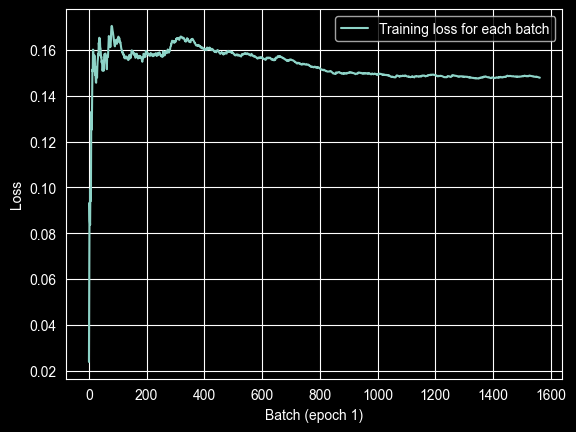

In [27]:
model = get_mnist_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(train_images,
    train_labels,
    epochs=2,
    callbacks=[LossHistory()],
    validation_data=(val_images, val_labels),
)

### Tensorboard

In [30]:
model = get_mnist_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

tensorboard = keras.callbacks.TensorBoard(
    log_dir="",
)

model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels),
    callbacks=[tensorboard],
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9129 - loss: 0.2909 - val_accuracy: 0.9581 - val_loss: 0.1363
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9559 - loss: 0.1447 - val_accuracy: 0.9705 - val_loss: 0.1002
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9642 - loss: 0.1157 - val_accuracy: 0.9733 - val_loss: 0.0896
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9700 - loss: 0.0967 - val_accuracy: 0.9750 - val_loss: 0.0863
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9726 - loss: 0.0855 - val_accuracy: 0.9767 - val_loss: 0.0821
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9754 - loss: 0.0753 - val_accuracy: 0.9764 - val_loss: 0.0824
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9781 - loss: 0.0682 - val_accuracy: 0.9778 - val_loss: 0.0820
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9791 - loss: 0

In [32]:
%load_ext tensorboard
%tensorboard --logdir train

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
